# <b><font color='teal'>Homework 17</font></b>

In [14]:
# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

##### <b><font color='teal'>Задание 1</font></b>
Рассчитайте 95% доверительный интервал для доли генеральной совокупности.<br>
Инструкции:
- Смоделируйте опрос населения, в котором 1000 человек отвечают на бинарный вопрос (да/нет). Предположим, что 600 человек ответили "Да".
- Из этой популяции сделайте выборку из 100 ответов.
- Рассчитайте долю ответов "Да" в выборке.
- Вычислите 95%-ный доверительный интервал для популяционной доли ответов "Да".
- Обсудите, как доверительный интервал дает информацию о доле населения.

<b>Короткий ответ:</b> доверительный интервал показывает не одно точное число, а разумный диапазон, в котором, скорее всего, находится истинная доля населения. Чем уже интервал, тем точнее оценка. Если интервал широкий, значит неопределенность выше.

In [2]:
# В переменные population_size, yes_count, no_count, sample_size, confidence
# запишите размер популяции, кол-во ответов "Да", кол-во ответов "Нет", размер выборки и точность ДИ соответственно
population_size = 1000
yes_count = 600
no_count = 400
sample_size = 100
confidence = 0.95

In [8]:
# Создайте массив population в котором будет соответствующее значение 0 и 1 (400 и 600)
population = np.array([1] * yes_count + [0] * no_count)
# display(population)

In [9]:
# Сгенерируйте случайную выборку с помощью np.random.choice
# Результат запишите в переменную sample
# (Синтаксис в файле "ЦПТ" - п.1.1)
np.random.seed(42)
sample = np.random.choice(population, size=sample_size, replace=False)
display(sample)

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0])

In [12]:
# Посчитайте долю ответов "Да" в выборке (sample)
# Результат запишите в переменную p
p = np.mean(sample)
print(f"Доля ответов 'Да' в выборке: {p*100:.2f}%")

Доля ответов 'Да' в выборке: 61.00%


In [13]:
# С помощью функции proportion_confint вычислите 95% ДИ для доли
# (Синтаксис в файле "ДИ" - п. "ДИ для доли ГС")
alpha = 1 - confidence
ci = proportion_confint(count=int(sample.sum()), nobs=sample_size, alpha=alpha, method="normal")
print(f"95% ДИ для доли 'Да': ({ci[0]*100:.2f}%, {ci[1]*100:.2f}%)")

95% ДИ для доли 'Да': (51.44%, 70.56%)


##### <b><font color='teal'>Задание 2</font></b>
Продемонстрируйте влияние размера выборки на форму распределения средних, используя равномерное распределение.

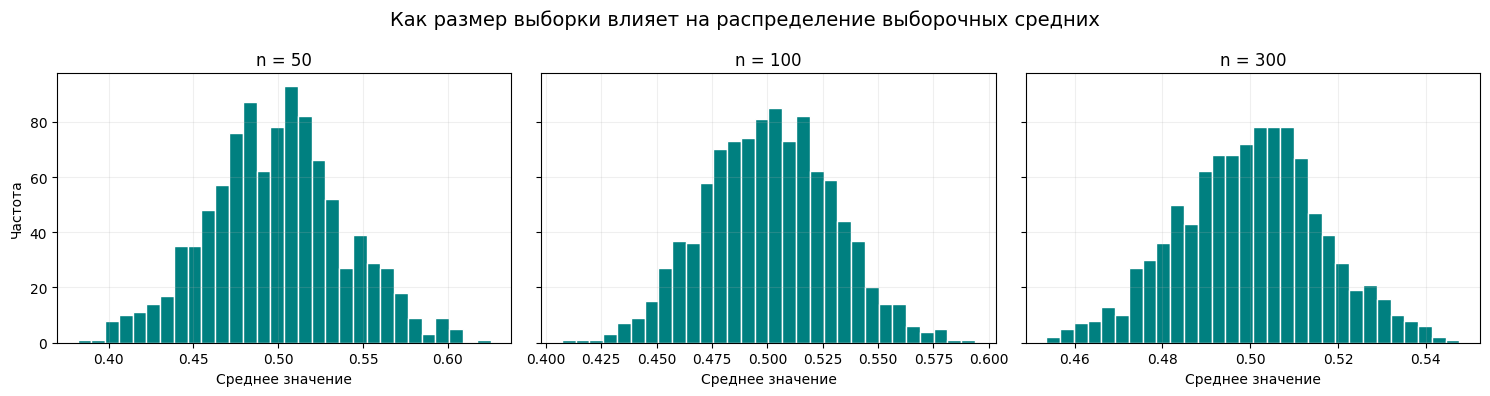

При увеличении размера выборки распределение средних становится более узким и ближе к нормальному.


In [19]:
# Задание 2. Влияние размера выборки на распределение средних
np.random.seed(42)

# Это продолжение идеи из задания 1: мы снова много раз моделируем выборки
# только теперь вместо бинарных ответов берем значения из равномерного распределения U(a, b)
# a и b - нижняя и верхняя границы равномерного распределения
a = 0
b = 1

# sample_sizes - размеры выборок, чтобы сравнить, как меняется форма распределения средних
# Маленькая выборка дает более широкий разброс, большая - более узкое и гладкое распределение
# Набор размеров взят для наглядного сравнения: от средней к крупной выборке
sample_sizes = [50, 100, 300]
num_samples = 1000

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 4), sharey=True)

for axis, sample_size in zip(axes, sample_sizes):
    sample_means = []
    for _ in range(num_samples):
        sample = np.random.uniform(a, b, size=sample_size)
        sample_means.append(sample.mean())

    axis.hist(sample_means, bins=30, color='teal', edgecolor='white')
    axis.set_title(f'n = {sample_size}')
    axis.set_xlabel('Среднее значение')
    axis.grid(alpha=0.2)

axes[0].set_ylabel('Частота')
fig.suptitle('Как размер выборки влияет на распределение выборочных средних', fontsize=14)
plt.tight_layout()
plt.show()

print('При увеличении размера выборки распределение средних становится более узким и ближе к нормальному.')